# Lab: Data Visualization and Visual Thinking

The U.S. Bureau of Transportation Statistics collects information about scheduled domestic flights. In this lab, you will use the ideas from **Data Visualization and Visual Thinking** to examine a documented sample of 5,000 completed, non-diverted flights from May 2026.


## Learning goals

By the end of this lab, you should be able to:

- load and inspect a CSV file as a Pandas DataFrame;
- distinguish Pandas data types from quantitative and categorical feature types;
- check for missing values;
- create and label a histogram and a bar chart;
- describe a distribution by its typical values, range, and skew;
- use `.describe()` to check estimates made from a histogram;
- explain how histogram bins and axis scales affect a figure; and
- identify conclusions that can and cannot be supported by a sample.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You are still responsible for understanding every part of your submission and checking suggestions against your notebook's output. At the end of the lab, disclose whether you used an AI tool and how you evaluated its advice.


## Dataset

Each observation represents one completed, non-diverted domestic flight in the sample.

| Feature | Description |
| --- | --- |
| `airline` | Airline that reported the flight |
| `origin_city` | Departure city |
| `destination_city` | Arrival city |
| `distance_miles` | Nonstop flight distance in miles |
| `arrival_delay_minutes` | Minutes between scheduled and actual arrival; negative values mean the flight arrived early |

See `data/README.md` for source, sampling, and preparation details.


## Load and preview the data

Import Pandas using the conventional alias `pd`. Read `data/bts_flights_may_2026_sample.csv` into a DataFrame named `flights`.


In [47]:
# Write your code here.
import pandas as pd

flights = pd.read_csv("data/bts_flights_may_2026_sample.csv")

Display the first five rows of the DataFrame.


In [48]:
# Write your code here.
flights.head()

,airline,origin_city,destination_city,distance_miles,arrival_delay_minutes
0,Alaska Airlines,"Anchorage, AK","Chicago, IL",2846,65
1,Alaska Airlines,"Anchorage, AK","Cordova, AK",160,-1
2,Alaska Airlines,"Anchorage, AK","Fairbanks, AK",261,-18
3,Alaska Airlines,"Anchorage, AK","Juneau, AK",571,-21
4,Alaska Airlines,"Anchorage, AK","Juneau, AK",571,-14


Display the last five rows of the DataFrame.


In [49]:
# Write your code here.
flights.tail()

,airline,origin_city,destination_city,distance_miles,arrival_delay_minutes
4995,United Airlines,"West Palm Beach/Palm Beach, FL","Chicago, IL",1144,0
4996,United Airlines,"West Palm Beach/Palm Beach, FL","Houston, TX",956,-22
4997,United Airlines,"West Palm Beach/Palm Beach, FL","Houston, TX",956,-29
4998,United Airlines,"West Palm Beach/Palm Beach, FL","Newark, NJ",1024,-26
4999,United Airlines,"West Palm Beach/Palm Beach, FL","Newark, NJ",1024,7


## Inspect the DataFrame

Display a summary of the DataFrame that includes the feature names, the number of non-missing values, and the Pandas data types.


In [50]:
# Write your code here.
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   airline                5000 non-null   object
 1   origin_city            5000 non-null   object
 2   destination_city       5000 non-null   object
 3   distance_miles         5000 non-null   int64 
 4   arrival_delay_minutes  5000 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 195.4+ KB


**How many observations are in the DataFrame?**

Your answer: 5000 entries


Count the missing values in every feature.


In [51]:
# Write your code here.
flights.isnull().sum()

airline                  0
origin_city              0
destination_city         0
distance_miles           0
arrival_delay_minutes    0
dtype: int64

## Classify the features

A **quantitative feature** records an amount or measurement for which arithmetic is meaningful. A **categorical feature** assigns observations to groups or labels.


**Complete the table with the Pandas data type and feature type of each feature.**

| Feature | Pandas data type | Feature type |
| --- | --- | --- |
| `airline` | object | categorical |
| `origin_city` | object | categorical |
| `destination_city` | object | categorical |
| `distance_miles` | int64 | quantitative |
| `arrival_delay_minutes` | int64 | quantitative |


## Which destination city is most common in the sample?

Calculate and display the frequency of each destination city. Save the result as `destination_counts`.


In [52]:
# Write your code here.
destination_counts = flights["destination_city"].value_counts()

flights["destination_city"].value_counts()

destination_city
Chicago, IL                      296
Atlanta, GA                      222
Dallas/Fort Worth, TX            210
Denver, CO                       209
Washington, DC                   165
                                ... 
Marquette, MI                      1
Cedar City, UT                     1
Sun Valley/Hailey/Ketchum, ID      1
Carlsbad, CA                       1
Redding, CA                        1
Name: count, Length: 238, dtype: int64

Import `matplotlib.pyplot` using the conventional alias `plt`. Use `.head(10)` on `destination_counts` to select the ten most frequent destination cities, then create a bar chart. Give the figure a descriptive title and label both axes.


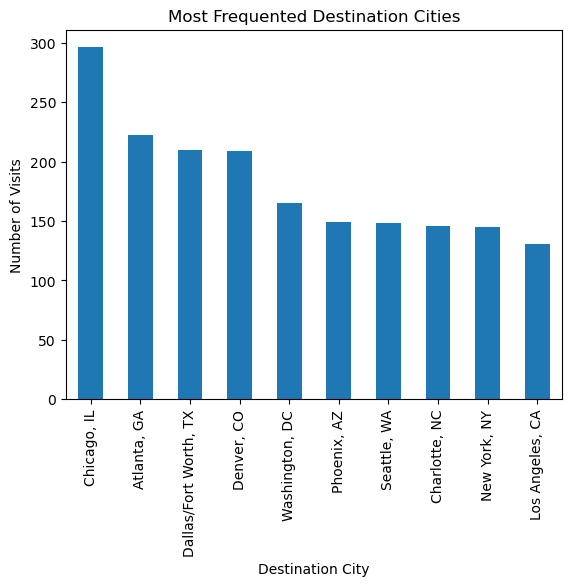

In [53]:
# Write your code here.
import matplotlib.pyplot as plt

destination_counts.head(10)
destination_counts.head(10).plot(kind="bar")

plt.title('Most Frequented Destination Cities')
plt.ylabel('Number of Visits')
plt.xlabel('Destination City')
plt.show()

**Which destination city is most common in the sample?**

Your answer: Chicago, IL with 296 instances


## What was the distribution of arrival delays?

Negative values represent early arrivals, zero represents an on-time arrival, and positive values represent late arrivals.

Create a histogram of `arrival_delay_minutes` using the default number of bins. Give the figure a descriptive title and label both axes.


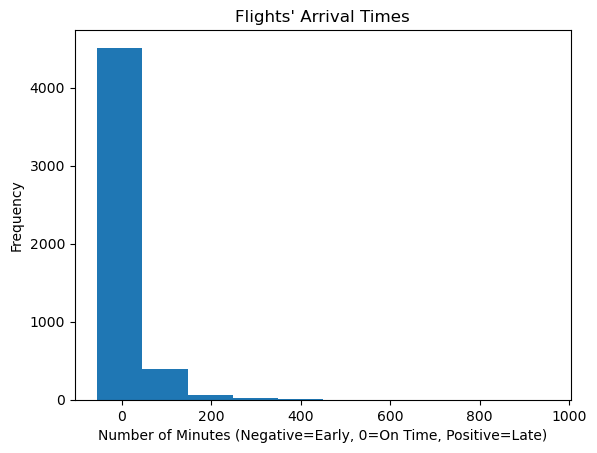

In [54]:
# Write your code here.
flights['arrival_delay_minutes'].plot(kind='hist')

plt.title("Flights' Arrival Times")
plt.ylabel('Frequency')
plt.xlabel('Number of Minutes (Negative=Early, 0=On Time, Positive=Late)')
plt.show()

**Approximately what arrival-delay value appears most common?**

Your answer: By viewing the histogram and making an approximation, the most common arrival delay value is between -25 and +25


**What is the approximate range from the smallest to the largest arrival-delay value?**

Your answer: The smallest would be around the -25 minute mark, while the largest would be around 440 minutes. This is an approximate range of 446 minutes.


**Does the arrival-delay distribution appear symmetric or skewed?**

Your answer: The distribution is right-skewed. Most of the arrival times are very near their estimated arrival times, either slightly early or slightly late. Then there is a steep drop off to arrival times that are as late as 400+ minutes.


Display a numerical summary of `arrival_delay_minutes`.


In [55]:
# Write your code here.
flights["arrival_delay_minutes"].describe()

count    5000.000000
mean        6.098800
std        48.335493
min       -55.000000
25%       -16.000000
50%        -6.000000
75%        10.000000
max       953.000000
Name: arrival_delay_minutes, dtype: float64

Calculate and display the exact mode of `arrival_delay_minutes` using `.mode()`.


In [56]:
# Write your code here.
flights["arrival_delay_minutes"].mode()

0   -8
Name: arrival_delay_minutes, dtype: int64

**How closely did the calculated mode match the most common value you estimated from the histogram?**

Your answer: The common value shown in the histogram was wide, showing between an estimated -25 to +25. The actual mode being -8 falls within that, but it's slightly left of the center of the histogram's range. 


**How closely did the minimum and maximum from `.describe()` match the range you estimated from the histogram?**

Your answer: The true minimum is -55 and the true maximum is 953. My estimates were pretty far off, with my minimum being closer to -25 and my maximum being around 440. The histogram didn't even seem to show the most extreme cases, the bins likely "hid" on the x-axis.


**Is the mean greater than, less than, or approximately equal to the median?**

Your answer: The mean is 6.0988, while the median is -6.  It is greater than.


**How is the relationship between the mean and median connected to the histogram's shape?**

Your answer: They are both in the left-most bin, but due to how right-skewed the graph is, the mean is increased significantly compared to the median of the graph.


## Applying the principles: histogram bins

Re-create the arrival-delay histogram using exactly 5 bins.


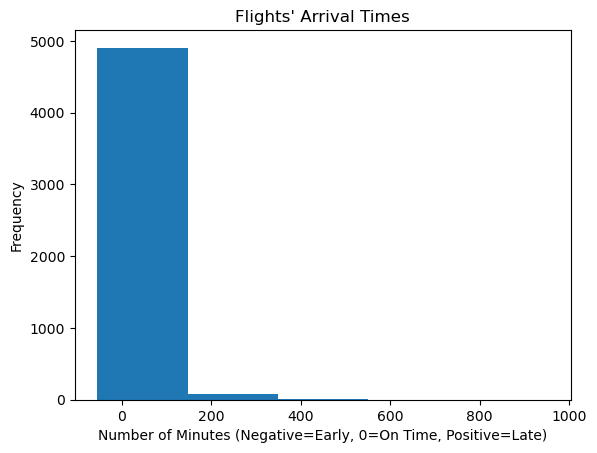

In [57]:
# Write your code here.
flights['arrival_delay_minutes'].plot(kind='hist', bins=5)

plt.title("Flights' Arrival Times")
plt.ylabel('Frequency')
plt.xlabel('Number of Minutes (Negative=Early, 0=On Time, Positive=Late)')
plt.show()

Re-create the arrival-delay histogram using exactly 25 bins.


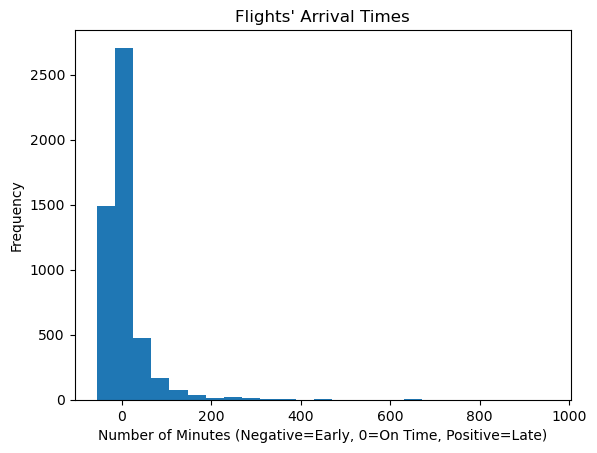

In [58]:
# Write your code here.
flights['arrival_delay_minutes'].plot(kind='hist', bins=25)

plt.title("Flights' Arrival Times")
plt.ylabel('Frequency')
plt.xlabel('Number of Minutes (Negative=Early, 0=On Time, Positive=Late)')
plt.show()

**What changed when the number of bins was reduced to 5?**

Your answer: It made it appear as if all/most of the data was in the first bin, from some negative number to just under 200.


**What changed when the number of bins was increased to 25?**

Your answer: It showed a greater grouping closer to and just above the 0 minute mark. I am also able to see some bins appear above the 600min mark as well, telling me my initial thought of the max being ~440min is way off. 


**Which bin setting communicates the distribution most clearly?**

Your answer: I'd say the 25 bins do, mainly for the reason stated in the question prior to this one. 


## Applying the principles: a misleading vertical axis

Run both cells below and compare the figures.


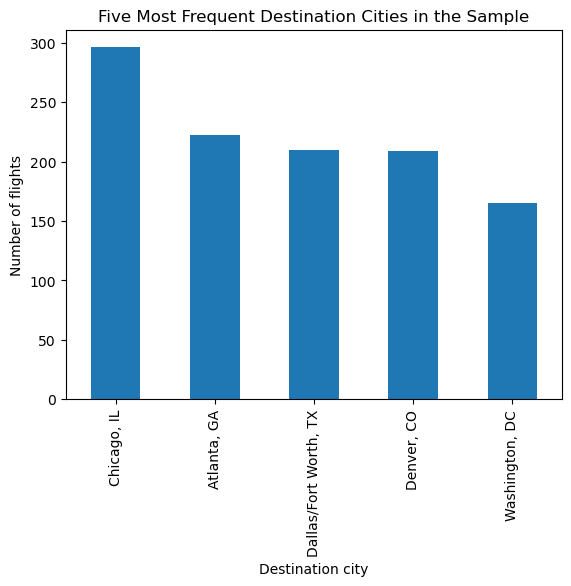

In [59]:
top_destinations = destination_counts.head(5)
top_destinations.plot(kind="bar")
plt.title("Five Most Frequent Destination Cities in the Sample")
plt.xlabel("Destination city")
plt.ylabel("Number of flights")
plt.show()


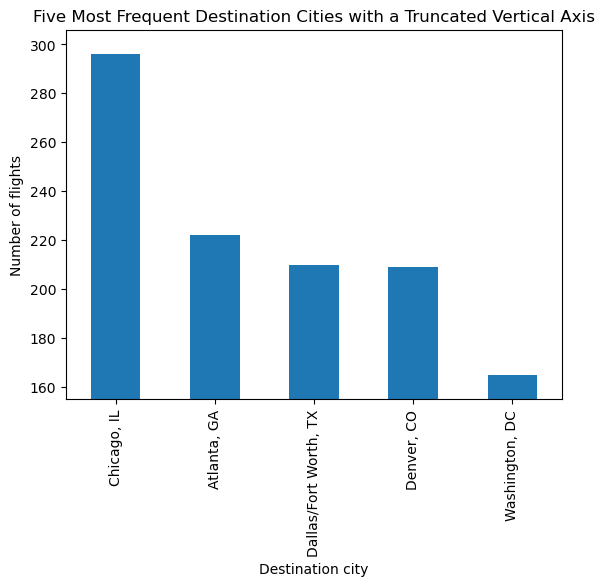

In [60]:
top_destinations.plot(kind="bar")
plt.ylim(top_destinations.min() - 10, top_destinations.max() + 10)
plt.title("Five Most Frequent Destination Cities with a Truncated Vertical Axis")
plt.xlabel("Destination city")
plt.ylabel("Number of flights")
plt.show()


**How does the truncated axis change the apparent differences among the destination cities?**

Your answer: It makes it seem as if Washington, DC has far fewer arrivals than the other cities listed in the top 5.


**Which chart communicates the counts more honestly?**

Your answer: The non-truncated y-axis, that goes from 0-300. It shows that while Washington, DC does have fewer arrivals than the top 4, this chart still shows a visual that is more honest at a glance.


## Is this sample representative?

Review `data/README.md` before answering these questions.


**What time period is represented by the source data?**

Your answer: May 2026


**Which flights were eligible to be included in the sample?**

Your answer: Completed, non-diverted domestic flights, with all five reported features having recorded values


**Which flights and records were excluded before the sample was selected?**

Your answer: Canceled flights, diverted flights, and any flights that were missing any of the five features


**Does finding no missing values in the sample prove that the original BTS data had no missing values?**

Your answer: No, it just means that the sample has no missing values...the population can still have missing values, since those flights were excluded from the sample.


**Why should conclusions from this sample not automatically be generalized to canceled or diverted flights?**

Your answer: As mentioned in the prior question, a sample is not the whole population. If it's curated to remove data with missing values, the data has been skewed and is not truly representative of the whole.


## Choosing a chart

Choose a histogram, bar chart, or pie chart for each question. These questions use features that you did not visualize earlier in the lab.


**Which chart would you use to show the frequency of each airline?**

Your answer: Bar chart


**Which chart would you use to show what share of sampled flights departed from each origin city?**

Your answer: Pie chart


**Which chart would you use to show the distribution of flight distances?**

Your answer: Histogram


## Reflect on AI assistance

Complete one of the following statements.

**If you used an AI tool:**

- Tool used:
- What I asked it to help with:
- One suggestion I checked against my code, chart, or output:
- What I accepted, modified, or rejected—and why:

**If you did not use an AI tool:**

- I did not use an AI tool for this assignment.
- One resource or troubleshooting strategy I used instead was:


Your response: I did not use an AI tool for this assignment. I referenced the Lecture notes from this morning.


## Submission checklist

- All code cells run from top to bottom without errors.
- The destination-city bar chart has a descriptive title and labeled axes.
- The default, 5-bin, and 25-bin arrival-delay histograms are included and labeled.
- Both vertical-axis demonstrations are included.
- Every question has one response in its own answer cell.
- The sample questions are answered using the dataset documentation.
- The AI-use reflection is complete and honest.
